# ISLP Chapter 12 Problem 13

## a)

In [ ]:
import pandas as pd
data = pd.read_csv('Ch12Ex13.csv', header = None);

## b)

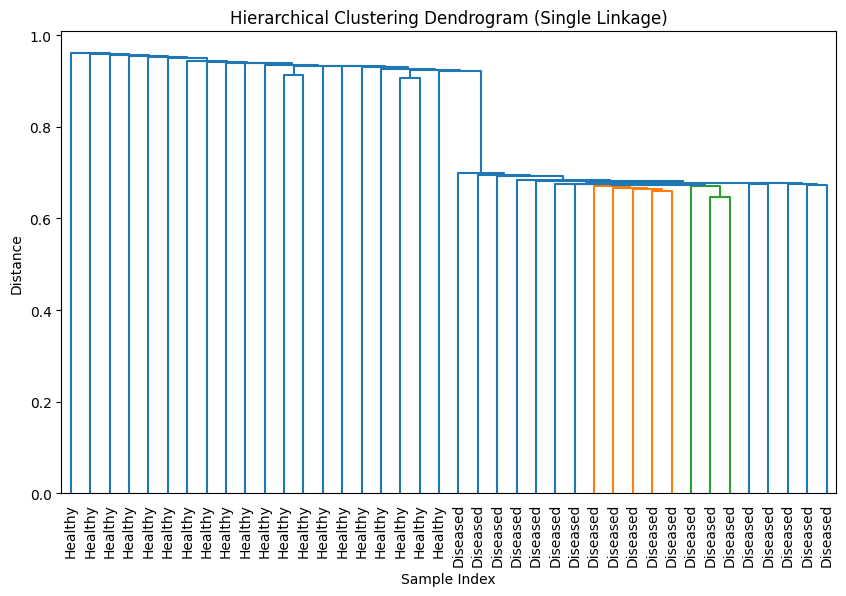

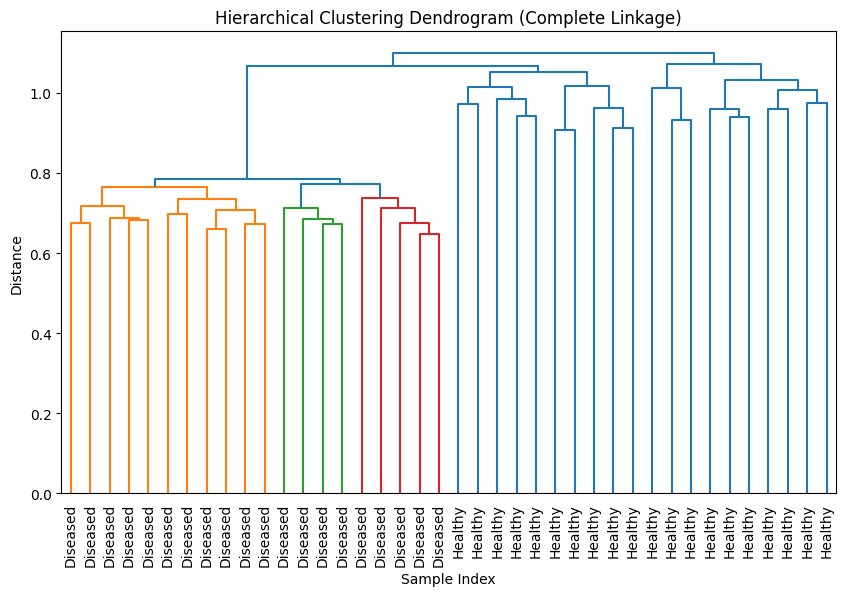

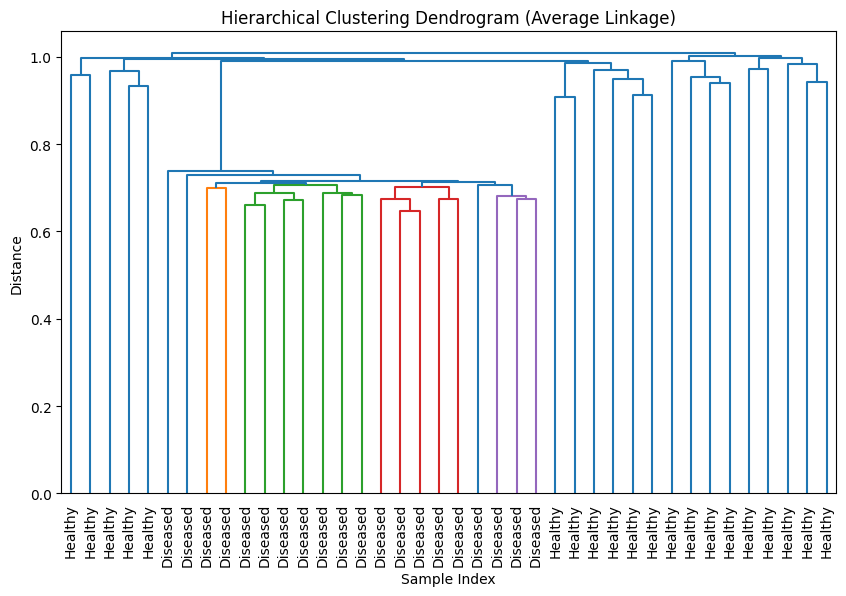

In [ ]:
import numpy as np
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import pdist
import matplotlib.pyplot as plt
import seaborn as sns

# Transpose the data to have samples as rows and genes as columns
data = data.T

# Create labels for the first 20 as "Healthy" and the next 20 as "Diseased"
labels = np.array(['Healthy'] * 20 + ['Diseased'] * 20)

# Calculate the correlation-based distance matrix between samples
correlation_distance = pdist(data, metric='correlation')

# Perform hierarchical clustering with different linkage methods
linkage_methods = ['single', 'complete', 'average']

for method in linkage_methods:
    Z = linkage(correlation_distance, method=method)

    # Plot the dendrogram
    plt.figure(figsize=(10, 6))
    dendrogram(Z, labels=labels, leaf_rotation=90, leaf_font_size=10)
    plt.title(f'Hierarchical Clustering Dendrogram ({method.capitalize()} Linkage)')
    plt.xlabel('Sample Index')
    plt.ylabel('Distance')
    plt.show()

### 1. **Separation of Samples**:
- **Single Linkage**:
  - This dendrogram shows a more elongated structure where many healthy samples remain clustered together, but the diseased samples are more spread out. There seems to be some overlap or mixed clusters, particularly at the lower heights, indicating that some diseased samples are close to healthy ones.
  
- **Complete Linkage**:
  - The complete linkage dendrogram shows a clearer separation of the two groups. The diseased samples tend to cluster together more distinctly, suggesting that genes provide a better separation of the two groups in this case. Healthy samples appear to be clustered separately, with minimal overlap.
  
- **Average Linkage**:
  - The average linkage dendrogram exhibits characteristics similar to complete linkage, with distinct clusters for diseased and healthy samples. However, there are also visible mixed clusters, indicating some healthy samples are close to diseased ones.

### 2. **Dependence on Type of Linkage**:
- **Single Linkage** tends to result in "chaining," where clusters can become elongated and may include samples that are not closely related. This can cause less distinct separation between groups.
  
- **Complete Linkage** provides tighter clusters and often yields better-defined groups because it considers the maximum distances between samples. This method seems to perform better in separating the two groups based on our results.
  
- **Average Linkage** offers a balance between single and complete linkage, often providing results that are reasonably clear but can still result in some ambiguity in cluster separation.

### Conclusion:
The genes do provide some separation between healthy and diseased samples, but the effectiveness varies with the linkage method used. The complete linkage method seems to give the clearest distinction between the two groups, while single linkage may lead to overlap and less clear separation.

## PCA

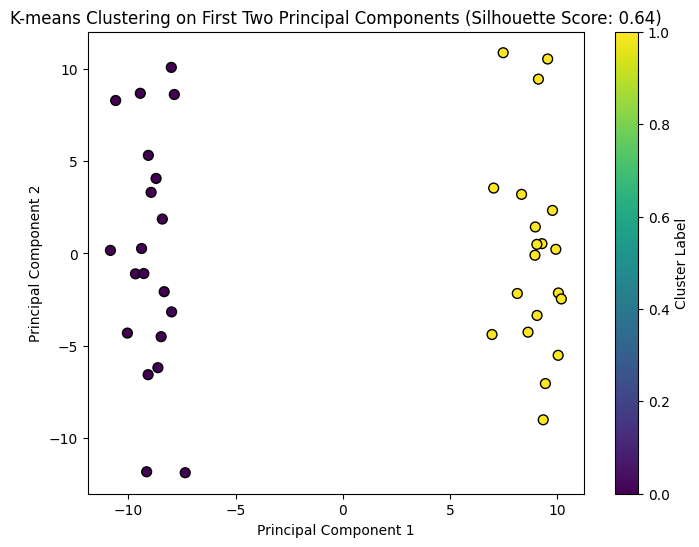

Silhouette Score for K-means clustering with K=2 on the first two principal components: 0.64


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

data = pd.read_csv('Ch12Ex13.csv', header = None)

# Transpose the data so that samples are rows and genes are columns
data = data.T

# Rescale (Standardize) the data
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)

# Apply PCA to reduce to the first two principal components
pca = PCA(n_components=2)
data_pca = pca.fit_transform(data_scaled)

# Perform K-means clustering with K=2
kmeans = KMeans(n_clusters=2, random_state=42)
cluster_labels = kmeans.fit_predict(data_pca)

# Calculate silhouette score
sil_score = silhouette_score(data_pca, cluster_labels)

# Plot the first two principal components with cluster labels
plt.figure(figsize=(8, 6))
plt.scatter(data_pca[:, 0], data_pca[:, 1], c=cluster_labels, cmap='viridis', marker='o', edgecolor='k', s=50)
plt.title(f'K-means Clustering on First Two Principal Components (Silhouette Score: {sil_score:.2f})')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(label='Cluster Label')
plt.show()

# Print silhouette score
print(f'Silhouette Score for K-means clustering with K=2 on the first two principal components: {sil_score:.2f}')


A silhouette score of **0.64** is a reasonably good clustering result. It suggests that the clusters are relatively well-defined and that points are closer to their own cluster than to other clusters. However there may still be some overlap or ambiguity.

In addition, the two principal components show a significant **separability** in the clustering plot. This suggests the following:

1. The principal components capture the variance in the data effectively for classification.

2. The PCA we run has effectively reduced the dimensionality while preserving the essential structure of the data.

3. Seperability combined with a silhouette score of 0.64, reinforces that K-means was appropriate for this dataset. It indicates that K-means can effectively model the cluster structure present in the data.

4. **Linear Classifier Potential**: Since the clusters appear to be linearly separable, we could apply linear classifiers (like Logistic Regression or a Linear Support Vector Machine) to achieve even better classification performance.

Overall, the clustering result appears to be promising, and the first two principal components seem to capture meaningful structure in our data for separating the two groups.